# Simple Linear Regression

***y = w * x + b***

In [198]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme()

In [199]:
# X represents our 'Feature' (the data we use to make predictions)
x = np.array([1 , 3, 4, 6, 7]) # Years of experience

# y represents our 'Target' (the value we want our model to learn to predict)
y = np.array([15, 35, 40, 65, 80]) # Salary in thousands

Text(0, 0.5, 'Salary in thousands')

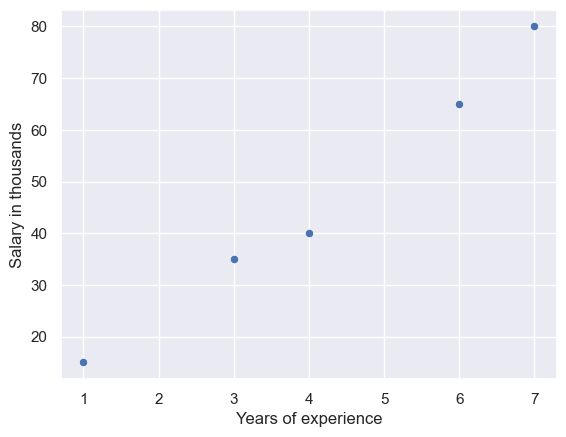

In [200]:
sns.scatterplot(x=x, y=y)

plt.xlabel("Years of experience")
plt.ylabel("Salary in thousands")

***Prediction Function***

In [201]:
def make_prediction(x, y, w, b):
    m = x.shape[0] # number of datapoint

    prediction_list = np.zeros((m,))

    for i in range(m):
        prediction_list[i] = w * x[i] + b

    return prediction_list

***Cost Function***

In [202]:
def compute_cost(x, y, w, b):
    
    m = x.shape[0] # number of datapoint

    cost = 0.0

    for i in range(m):
        ȳ = w * x[i] + b
        error = (ȳ - y[i]) ** 2
        cost += error

    mse = cost / 2 * m # mean square error

    return mse

Prediction: [15. 35. 45. 65. 75.]
Cost: 125.0


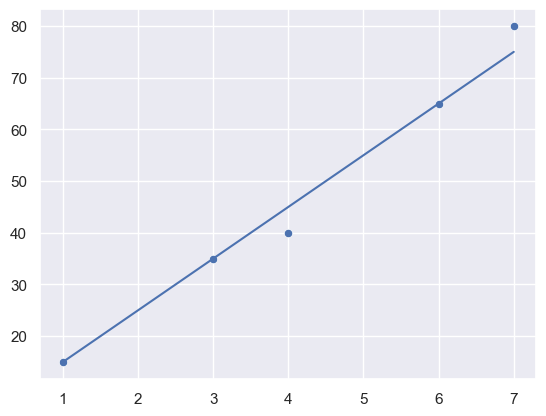

In [203]:
w = 10
b = 5

prediction = make_prediction(x, y, w=w, b=b)
cost = compute_cost(x, y, w=w, b=b)

print(f"Prediction: {prediction}")
print(f"Cost: {cost}")

sns.scatterplot(x=x, y=y)
plt.plot(x, prediction)

***Calculating Weight (w)***

Text(0, 0.5, 'Cost')

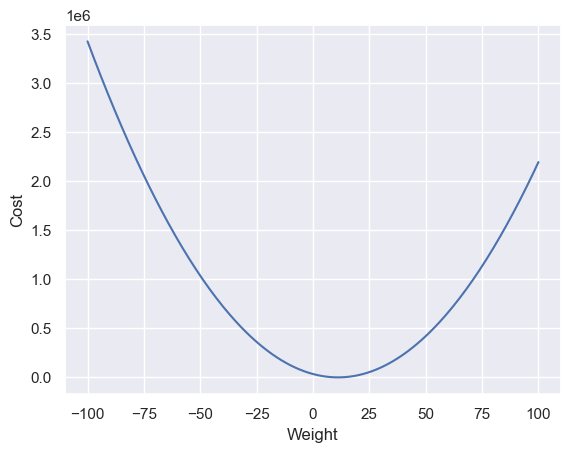

In [204]:
weight = []
cost_w = []

# w -> -100 to 100
for i in range (-100, 101):
    c = compute_cost(x, y, w=i, b=0) # let b = 0
    weight.append(i)
    cost_w.append(c)

plt.plot(weight, cost_w)
plt.xlabel("Weight")
plt.ylabel("Cost")

***Gradinet Function***

In [205]:
def calculate_gradint(x, y, w, b):

    m = x.shape[0]

    dj_dw = 0.0 # dj/dw = 1 / m * ∑ (ȳ - y) * x
    dj_db = 0.0 # dj/db = 1 / m * ∑ (ȳ - y)
    

    for i in range(m):
        ȳ = w * x[i] + b
        error = ȳ - y[i]

        dj_dw = dj_dw + (error * x[i])
        dj_db = dj_db + error

    dj_dw = dj_dw / m
    dj_db = dj_db / m

    return dj_dw, dj_db
    

***Gradient Descent Algorithm***

In [206]:
def gradient_descent(x, y, w_input, b_input, max_itr, alpha = 0.01):

    w = w_input
    b = b_input

    cost_memo = [] 
    iteration = []

    for i in range(max_itr):
        dj_dw, dj_db = calculate_gradint(x, y, w, b)

        # update
        w = w - alpha * dj_dw
        b = b - alpha * dj_db

        cost = compute_cost(x, y, w, b) # J(w,b)= ∑ ​(ȳ − y) ^ 2
        
        cost_memo.append(cost)
        iteration.append(i)

        if (i % 100) == 0:
            print(f"For i={i} th")
            print(f"Weight : {w:0.4f}")
            print(f"Bias : {b:0.4f}")
            print(f"Gradient (∂J/∂w) : {dj_dw:0.4f}")
            print(f"Gradient (∂J/∂b) : {dj_db:0.4f}")
            print(f"Cost : {cost:0.4f}")
            print("______________")

    return w, b, cost_memo, iteration


In [207]:
weight, bias, cost_memo, iter = gradient_descent(x, y, w_input=0, b_input=0, max_itr=10000, alpha=0.01)

For i=0 th
Weight : 2.4600
Bias : 0.4700
Gradient (∂J/∂w) : -246.0000
Gradient (∂J/∂b) : -47.0000
Cost : 20309.7313
______________
For i=100 th
Weight : 10.6884
Bias : 2.0771
Gradient (∂J/∂w) : 0.0061
Gradient (∂J/∂b) : -0.0317
Cost : 100.3945
______________
For i=200 th
Weight : 10.6829
Bias : 2.1058
Gradient (∂J/∂w) : 0.0050
Gradient (∂J/∂b) : -0.0260
Cost : 100.3730
______________
For i=300 th
Weight : 10.6784
Bias : 2.1294
Gradient (∂J/∂w) : 0.0041
Gradient (∂J/∂b) : -0.0213
Cost : 100.3586
______________
For i=400 th
Weight : 10.6747
Bias : 2.1488
Gradient (∂J/∂w) : 0.0033
Gradient (∂J/∂b) : -0.0175
Cost : 100.3489
______________
For i=500 th
Weight : 10.6717
Bias : 2.1646
Gradient (∂J/∂w) : 0.0027
Gradient (∂J/∂b) : -0.0143
Cost : 100.3423
______________
For i=600 th
Weight : 10.6692
Bias : 2.1776
Gradient (∂J/∂w) : 0.0022
Gradient (∂J/∂b) : -0.0118
Cost : 100.3380
______________
For i=700 th
Weight : 10.6672
Bias : 2.1883
Gradient (∂J/∂w) : 0.0018
Gradient (∂J/∂b) : -0.0096
Cost

In [208]:
print(w,b)

10 5


***Updated Cost***

Prediction: [12.89473684 34.21052632 44.86842105 66.18421053 76.84210526]
Cost: 100.3289


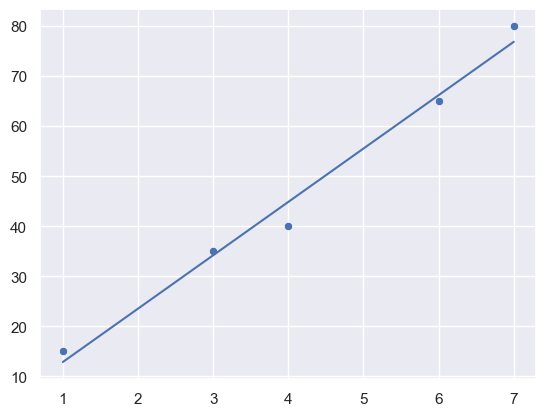

In [209]:
prediction = make_prediction(x, y, w=weight, b=bias)
cost = compute_cost(x, y, w=weight, b=bias)

print(f"Prediction: {prediction}")
print(f"Cost: {cost:0.4f}")

sns.scatterplot(x=x, y=y)
plt.plot(x, prediction)

***Testing***

In [210]:
# selary for x years experience employee
# ȳ = w * x + b
x = 2
ȳ = weight * x + bias

print(f"Selary for {x} years experience employee: {ȳ:0.4f}")

Selary for 2 years experience employee: 23.5526


Text(0, 0.5, 'Cost')

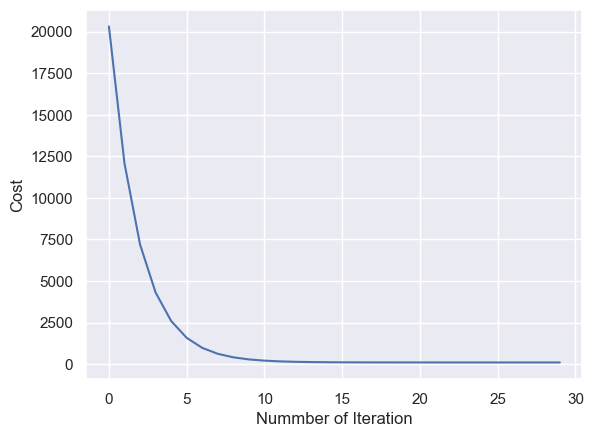

In [211]:
plt.plot(iter[:30], cost_memo[:30])
plt.xlabel("Nummber of Iteration")
plt.ylabel("Cost")